In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('FInal_SQL_Cleaned_Fact_Streampulse_Data_1.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_key                 15000 non-null  int64  
 1   age                      15000 non-null  int64  
 2   gender                   15000 non-null  object 
 3   country                  15000 non-null  object 
 4   user_segment             15000 non-null  object 
 5   lifetime_value_usd       15000 non-null  float64
 6   plan_name                15000 non-null  object 
 7   monthly_price            15000 non-null  float64
 8   genre                    15000 non-null  object 
 9   content_type             15000 non-null  object 
 10  device_type              15000 non-null  object 
 11  operating_system         15000 non-null  object 
 12  activity_date            15000 non-null  object 
 13  month_name               15000 non-null  object 
 14  year                  

In [5]:
df.head()

,user_key,age,gender,country,user_segment,lifetime_value_usd,plan_name,monthly_price,genre,content_type,...,login_count,pause_count,buffering_events,stream_quality,engagement_score,watch_efficiency,revenue_attributed_usd,subscription_event_type,cancellation_reason,churn_flag
0,1,56,Female,Germany,New User,424.27,Basic,7.99,Sci-Fi,Movie,...,3,4,3,480p,22.048,1.052352,1.13,Downgrade,NaN,0
1,1,56,Female,Germany,New User,424.27,Standard,13.99,Drama,Series,...,5,5,1,1080p,37.580,0.769354,1.90,Renewal,NaN,0
2,1,56,Female,Germany,New User,424.27,Premium,19.99,Romance,Series,...,1,5,2,720p,32.776,0.812240,1.49,NaN,NaN,0
3,2,46,Male,USA,Casual Viewer,358.20,Basic,7.99,Romance,Series,...,2,4,2,4K,49.444,0.928456,0.57,NaN,NaN,0
4,3,32,Male,Canada,Power User,326.60,Standard,13.99,Action,Movie,...,1,7,2,1080p,59.132,0.928401,2.11,NaN,NaN,0


In [7]:
df.describe()

,user_key,age,lifetime_value_usd,monthly_price,year,minutes_watched,session_duration_mins,completion_rate,login_count,pause_count,buffering_events,engagement_score,watch_efficiency,revenue_attributed_usd,churn_flag
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.0,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,249.702733,41.309133,409.250981,14.050400,2023.0,78.275853,86.054227,0.651074,4.993800,4.003000,2.004467,51.959214,0.918951,1.304765,0.056800
std,144.252551,13.450904,234.227948,4.912226,0.0,74.294885,82.477421,0.201393,2.580686,2.593191,1.417103,30.331653,0.097929,0.693766,0.231468
min,1.000000,18.000000,15.040000,7.990000,2023.0,1.020000,1.000000,0.300000,1.000000,0.000000,0.000000,9.852000,0.769128,0.100000,0.000000
25%,124.000000,30.000000,198.160000,7.990000,2023.0,26.570000,28.910000,0.480000,3.000000,2.000000,1.000000,31.650000,0.833068,0.710000,0.000000
50%,250.000000,42.000000,424.270000,13.990000,2023.0,52.430000,57.460000,0.650000,5.000000,4.000000,2.000000,41.950000,0.908235,1.300000,0.000000
75%,375.000000,52.000000,616.295000,19.990000,2023.0,87.885000,100.747500,0.830000,7.000000,6.000000,3.000000,58.999000,0.999324,1.910000,0.000000
max,500.000000,64.000000,798.370000,19.990000,2023.0,299.990000,386.060000,1.000000,9.000000,8.000000,4.000000,149.928000,1.111013,2.500000,1.000000


#### Missing values

In [10]:
df.isnull().sum()

user_key                       0
age                            0
gender                         0
country                        0
user_segment                   0
lifetime_value_usd             0
plan_name                      0
monthly_price                  0
genre                          0
content_type                   0
device_type                    0
operating_system               0
activity_date                  0
month_name                     0
year                           0
minutes_watched                0
session_duration_mins          0
completion_rate                0
login_count                    0
pause_count                    0
buffering_events               0
stream_quality                 0
engagement_score               0
watch_efficiency               0
revenue_attributed_usd         0
subscription_event_type     8988
cancellation_reason        14148
churn_flag                     0
dtype: int64

In [28]:
df['year'] = pd.to_datetime(df['year'],errors = 'coerce')
df['activity_date'] = pd.to_datetime(df['activity_date'],errors = 'coerce')


#### Business Insights:
- Subscription event type and cancellation reason have most misssing values.
- These are used to calculate churn rate.
- Thus these are the primary key factors in determing churn flag and they should not be removed.
- Necessary changes can be done when creating a model to predict churn flag.

#### UNIVARIATE ANALYSIS

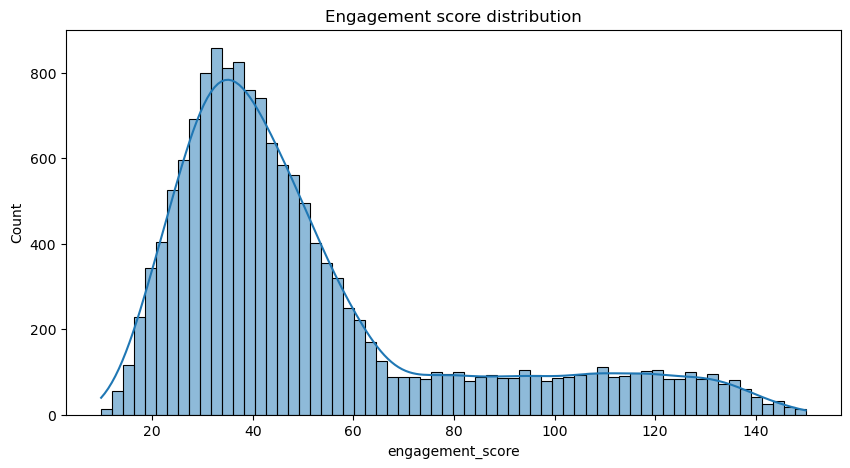

In [14]:
## ENGAGEMENT SCORE

plt.figure(figsize=(10,5))

sns.histplot(data = df,x = 'engagement_score',kde = True)
plt.title('Engagement score distribution')
plt.show()

#### Age distribution

(array([1230.,  594.,  543.,  778.,  515.,  420.,  933.,  483.,  475.,
         722., 1326.,  737.,  667., 1226.,  751.,  690.,  915.,  634.,
         527.,  834.]),
 array([18. , 20.3, 22.6, 24.9, 27.2, 29.5, 31.8, 34.1, 36.4, 38.7, 41. ,
        43.3, 45.6, 47.9, 50.2, 52.5, 54.8, 57.1, 59.4, 61.7, 64. ]),
 <BarContainer object of 20 artists>)

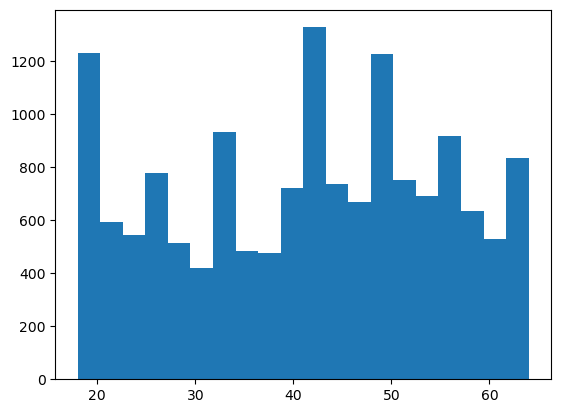

In [17]:
plt.hist(df["age"], bins=20)

#### Subscription Plans

<Axes: xlabel='plan_name'>

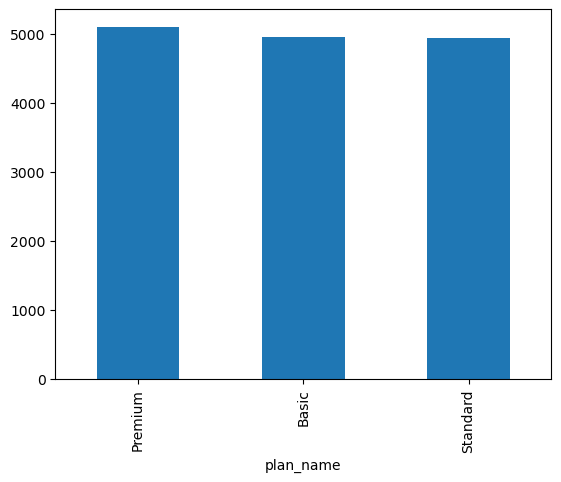

In [20]:
df["plan_name"].value_counts().plot(kind="bar")

#### minutes watched

(array([ 947., 1693., 1953., 1341., 1354., 1321., 1044.,  897.,  939.,
         173.,  163.,  157.,  176.,  137.,  159.,  156.,  176.,  198.,
         153.,  178.,  174.,  160.,  173.,  154.,  187.,  170.,  171.,
         167.,  185.,  144.]),
 array([  1.02      ,  10.98566667,  20.95133333,  30.917     ,
         40.88266667,  50.84833333,  60.814     ,  70.77966667,
         80.74533333,  90.711     , 100.67666667, 110.64233333,
        120.608     , 130.57366667, 140.53933333, 150.505     ,
        160.47066667, 170.43633333, 180.402     , 190.36766667,
        200.33333333, 210.299     , 220.26466667, 230.23033333,
        240.196     , 250.16166667, 260.12733333, 270.093     ,
        280.05866667, 290.02433333, 299.99      ]),
 <BarContainer object of 30 artists>)

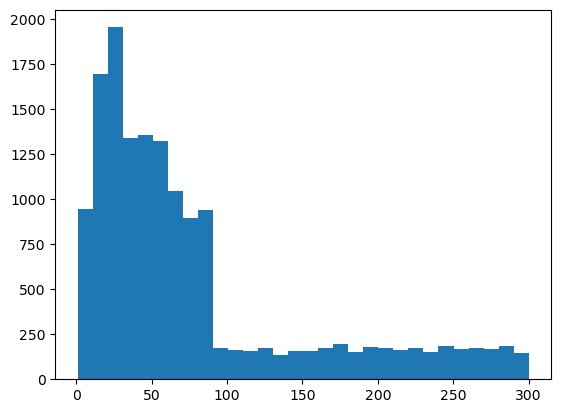

In [31]:
plt.hist(df["minutes_watched"], bins=30)

#### revenue attributed

(array([448., 501., 533., 534., 445., 489., 488., 480., 496., 491., 519.,
        508., 560., 492., 461., 590., 487., 430., 505., 558., 432., 465.,
        571., 422., 499., 519., 578., 509., 417., 573.]),
 array([0.1 , 0.18, 0.26, 0.34, 0.42, 0.5 , 0.58, 0.66, 0.74, 0.82, 0.9 ,
        0.98, 1.06, 1.14, 1.22, 1.3 , 1.38, 1.46, 1.54, 1.62, 1.7 , 1.78,
        1.86, 1.94, 2.02, 2.1 , 2.18, 2.26, 2.34, 2.42, 2.5 ]),
 <BarContainer object of 30 artists>)

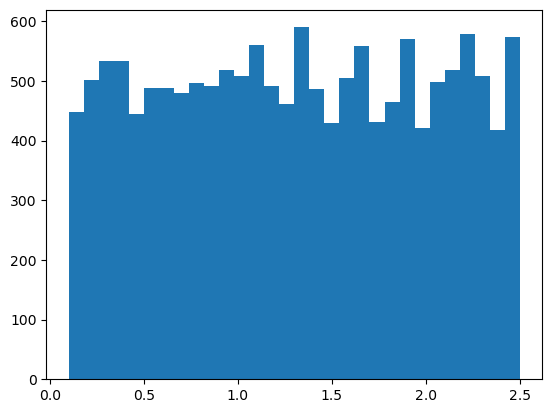

In [34]:
plt.hist(df["revenue_attributed_usd"], bins=30)

#### BIVARIATE ANNALYSIS

In [37]:
pd.crosstab(df["plan_name"],df["churn_flag"])

churn_flag,0,1
plan_name,,
Basic,4651,301
Premium,4844,259
Standard,4653,292


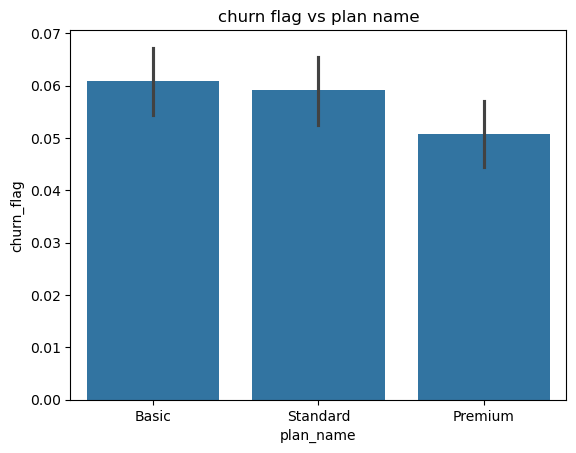

In [39]:
sns.barplot(data = df,x = 'plan_name',y = 'churn_flag')
plt.title('churn flag vs plan name')
plt.show()

#### Business Insights:
- We can observe that churn rate is higher in basic plan.

In [42]:
pd.crosstab(df["device_type"],df["churn_flag"])

churn_flag,0,1
device_type,,
Desktop,3538,229
Mobile,3529,209
Smart TV,3544,217
Tablet,3537,197


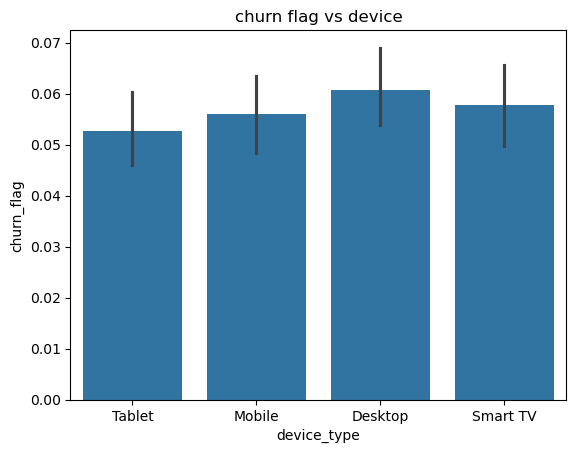

In [44]:
sns.barplot(data = df,x = 'device_type',y = 'churn_flag')
plt.title('churn flag vs device')
plt.show()

#### Business Insigts:
- We can observe that higher churn is observed from desktop and smart Tv devices.

In [47]:
pd.crosstab(df["genre"],df["churn_flag"])

churn_flag,0,1
genre,,
Action,1788,94
Animation,1203,65
Comedy,1382,68
Documentary,1749,135
Drama,1887,123
Horror,1564,87
Romance,1875,121
Sci-Fi,1422,86
Thriller,1278,73


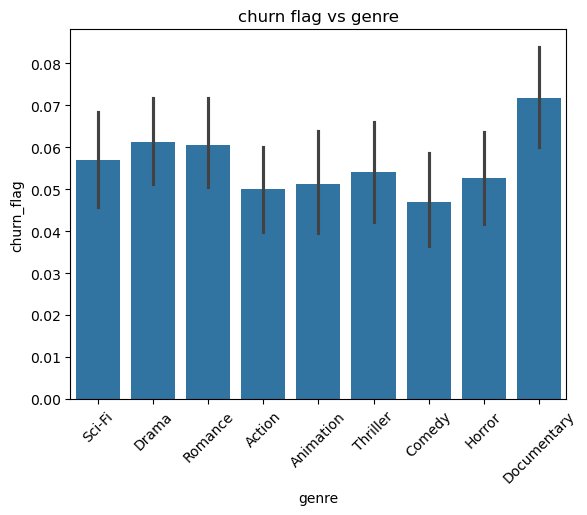

In [51]:
sns.barplot(data = df,x = 'genre',y = 'churn_flag')
plt.title('churn flag vs genre')
plt.xticks(rotation = 45)
plt.show()

#### Business Insights:
- We can observe that higher churn rate is obtained from documentray genre.
- Least churn rate is observed from comedy genre.

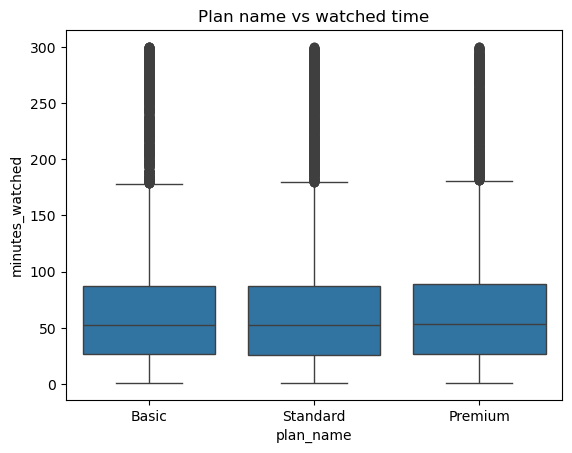

In [58]:
sns.boxplot(data = df,x='plan_name',y = 'minutes_watched')
plt.title('Plan name vs watched time')
plt.show()

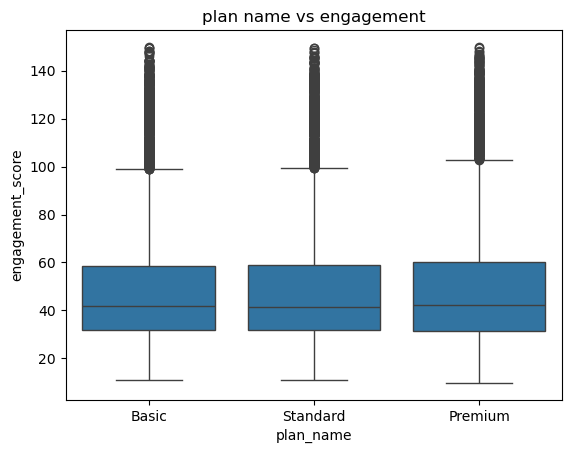

In [60]:
sns.boxplot(data = df,x = 'plan_name',y = 'engagement_score')
plt.title('plan name vs engagement')
plt.show()

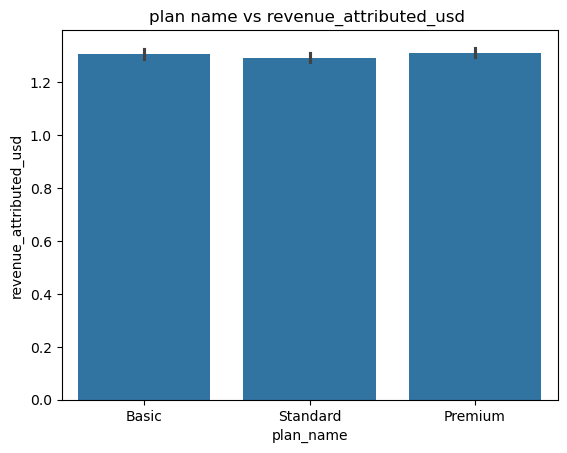

In [66]:
sns.barplot(data = df,x = 'plan_name',y ='revenue_attributed_usd')
plt.title('plan name vs revenue_attributed_usd ')
plt.show()

### MULTIVARIATE ANALYSIS

#### CORRELATION ANALYSIS

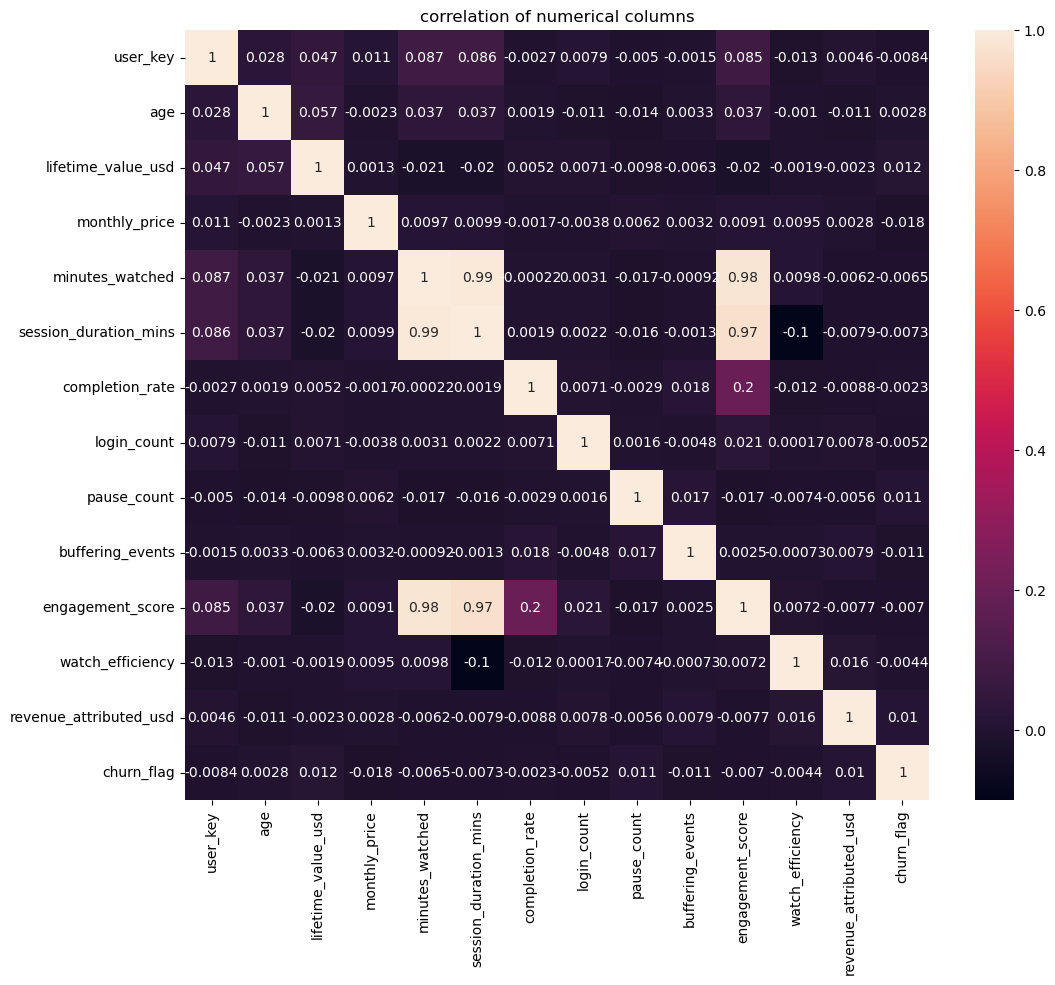

In [78]:
num=df.select_dtypes(include=np.number)
plt.figure(figsize=(12,10))
sns.heatmap(num.corr(),annot = True)
plt.title('correlation of numerical columns')
plt.show()

#### BUSINESS KPIs

In [82]:
churn_rate = df["churn_flag"].mean()*100
print(churn_rate)

5.680000000000001


In [85]:
average_engagement = df["engagement_score"].mean()
print(average_engagement)

51.9592144


In [87]:
average_revenue = df["revenue_attributed_usd"].mean()
print(average_revenue)

1.3047653333333333


In [89]:
average_watchtime = df["minutes_watched"].mean()
print(average_watchtime)

78.27585266666667


In [93]:
average_CLV = df["lifetime_value_usd"].mean()
print(average_CLV)

409.2509813333333


#### Business Insights:
- One useful finding from your data is the ranking of genres by total watch time:

- Rank	Genre
- 1	Drama
- 2	Romance
- 3	Action
- 4	Documentary
- 5	Horror

- This supports content consumption analysis and can be useful when discussing content strategy.